# Olist Brazilian E-Commerce — Consolidated EDA
## Team 5 · IT5006 · AY2026/27 Semester 1 — Phase 1 (Literature Review & EDA)

Covers the dataset and
data quality, temporal patterns, the customer / seller / product distributions, relationships between
variables, and a preliminary investigation of the candidate analytics problems to be scoped in
Phase 2. Every chart is read for two things: **what it implies for our choice of problem**, and
**whether the underlying data is usable**.

*Team 5 — Gan Zi Qing, Lam Pei Shi, Li Keyou, Lim Yunhui Trixie, Siow Hui Xin.*

## 0. Setup and data loading

We load the nine Olist tables, parsing all date columns up front. The loader searches a list of
common locations (Colab Drive, the repo `data/` folder, an `OLIST_DATA_DIR` override) so the same
notebook runs unchanged for every team member. The shape of each table is printed to get an overview of the data that we are working with.

Some shared settings for libraries are also set here.

In [59]:
import os, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

RANDOM_STATE = 42   # documented seed, used for every sampling / split below
np.random.seed(RANDOM_STATE)

In [60]:
# Try to mount Google Drive when running on Colab (silently skipped elsewhere)
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    pass

def find_data_dir():
    candidates = []
    if os.environ.get("OLIST_DATA_DIR"):
        candidates.append(os.environ["OLIST_DATA_DIR"])
    candidates += [
        "/content/drive/MyDrive/IT5006_Project/Olist_CSV",
        "/content/drive/Othercomputers/My laptop/NUS/11_IT5006 Fundamentals of Data Analytics/03_Project/IT5006_Project-Data/Olist_CSV",
        "data", "../data", "Olist_CSV", "../Olist_CSV",
    ]
    for c in candidates:
        if c and os.path.exists(os.path.join(c, "olist_orders_dataset.csv")):
            return c
    raise FileNotFoundError(
        "Could not locate the Olist CSVs. Set OLIST_DATA_DIR or place the files in ./data/.")

DATA_DIR = find_data_dir()
print("Reading data from:", DATA_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Reading data from: /content/drive/Othercomputers/My laptop/NUS/11_IT5006 Fundamentals of Data Analytics/03_Project/IT5006_Project-Data/Olist_CSV


In [61]:
DATE_COLS = {
    "orders": ["order_purchase_timestamp", "order_approved_at",
               "order_delivered_carrier_date", "order_delivered_customer_date",
               "order_estimated_delivery_date"],
    "items": ["shipping_limit_date"],
    "reviews": ["review_creation_date", "review_answer_timestamp"],
}
FILES = {
    "orders": "olist_orders_dataset.csv", "items": "olist_order_items_dataset.csv",
    "payments": "olist_order_payments_dataset.csv", "reviews": "olist_order_reviews_dataset.csv",
    "customers": "olist_customers_dataset.csv", "sellers": "olist_sellers_dataset.csv",
    "products": "olist_products_dataset.csv", "geolocation": "olist_geolocation_dataset.csv",
    "cat_trans": "product_category_name_translation.csv",
}
t = {name: pd.read_csv(os.path.join(DATA_DIR, fn), parse_dates=DATE_COLS.get(name))
     for name, fn in FILES.items()}
for name, df in t.items():
    print(f"{name:14s} {df.shape[0]:>9,} rows x {df.shape[1]} cols")

orders            99,441 rows x 8 cols
items            112,650 rows x 7 cols
payments         103,886 rows x 5 cols
reviews           99,224 rows x 7 cols
customers         99,441 rows x 5 cols
sellers            3,095 rows x 4 cols
products          32,951 rows x 9 cols
geolocation    1,000,163 rows x 5 cols
cat_trans             71 rows x 2 cols


## 1. Dataset overview — tables, joins, row counts

To get a sense of how the dataset tables are related, we first reviewed which tables share the same headers. These are potential join keys. The dataset is nine relational tables centred on `orders` and `order_items`.
directly or through `order_items`.
We reviewed the dataset and also took references from other ERD diagarms found on the Kaggle website. The final ERD diagram is presented in the report.

Data Structure:
* `orders` and `reviews` are one row per order
* `customers` is one row per customer_id, each customer_unique_id can have several entries
* `order_items` is one row per **item line**, and an order can have several entries distinguished by the order_itm_id
* `payments` is one row per payment instalment record, and an order can have multiple entries distinguished by payment_installments

A few structural facts the whole team relies on:
- `customer_id` is issued **per order**; the real person is `customer_unique_id`.
- `order_items.order_item_id` is a line counter within an order (max 21), not a product id.
- `geolocation` has many rows per zip prefix and ~262k exact duplicates, so it must be reduced to one coordinate per zip before use

In [62]:
# Which columns are shared across tables — i.e. the join keys
from collections import defaultdict
col_tables = defaultdict(list)
for name, df in t.items():
    for c in df.columns:
        col_tables[c].append(name)
print("Join keys (columns shared by >1 table):")
for c, v in col_tables.items():
    if len(v) > 1:
        print(f"  {c:26s} links  {', '.join(v)}")

Join keys (columns shared by >1 table):
  order_id                   links  orders, items, payments, reviews
  customer_id                links  orders, customers
  product_id                 links  items, products
  seller_id                  links  items, sellers
  product_category_name      links  products, cat_trans


In [63]:
overview = []
for name, df in t.items():
    overview.append({
        "table": name, "rows": len(df), "cols": df.shape[1],
        "total_missing_cells": int(df.isna().sum().sum()),
        "exact_dup_rows": int(df.duplicated().sum()),
    })
overview = pd.DataFrame(overview).set_index("table")
overview

,rows,cols,total_missing_cells,exact_dup_rows
table,,,,
orders,99441,8,4908,0
items,112650,7,0,0
payments,103886,5,0,0
reviews,99224,7,145903,0
customers,99441,5,0,0
sellers,3095,4,0,0
products,32951,9,2448,0
geolocation,1000163,5,0,261831
cat_trans,71,2,0,0


In [64]:
print("Distinct customer_id       :", t['customers']['customer_id'].nunique())
print("Distinct customer_unique_id:", t['customers']['customer_unique_id'].nunique())
print("Orders in order_items      :", t['items']['order_id'].nunique(),
      "| max items in one order:", int(t['items']['order_item_id'].max()))
print("Geolocation rows           :", len(t['geolocation']),
      "| distinct zip prefixes:", t['geolocation']['geolocation_zip_code_prefix'].nunique())
print("Date range (purchases)     :",
      t['orders']['order_purchase_timestamp'].min().date(), "to",
      t['orders']['order_purchase_timestamp'].max().date())

Distinct customer_id       : 99441
Distinct customer_unique_id: 96096
Orders in order_items      : 98666 | max items in one order: 21
Geolocation rows           : 1000163 | distinct zip prefixes: 19015
Date range (purchases)     : 2016-09-04 to 2018-10-17


## 2. Data quality

To review the data quality, we reviewed the number of missing fields in each table.

### 2.1 Missing Data
##### **Table: Orders**
Following the results above, we manually inspect the data to see what could be the causes of the missing rows.
For the orders table, the missing rows is likely not an error, but rather that some order dates are not available for certain entries. E.g. if the order was cancelled before it is approved, it would only contain the order_purchase_timestamp and order_estimated_delivery_date, with the rest of the date columns left empty.

This finding highlights that any further analysis related to order dates will have to account for this behaviour in the data.

##### **Table: Reviews**
There is a high percentage of missing fields the reviews table for the comments title and message. This finding highlights that if we wanted to do any analysis related to review title or message, it will severly limit the size of the dataset that we have. Instead, analysis that involve the Review table should take information from the rewiew_score column instead, which does not have any missing fields.  

##### **Table: Product**
While there are missing data found in this table, they are a relatively small percentage of the dataset. Nonetheless, these rows should be removed from the dataset prior to analysis if thehy are relevant to the analysis.

### 2.2 Other Data Issues
City name columns are unreliable
* Affected columns: `geolocation_city`, `customer_city`, `seller_city`
* Issue: The same city under accented and plain spellings plus stray HTML-/URL-encoded and parenthetical values, this will cause issues when using the city names as
* Example: `sao paulo` 135.8k rows vs `são paulo` 24.9k

Freight Ratio
* Affected columns: 'freight_value'
* Some freight values = 0, this will cause issues when calculating freight ratios due to division by 0
* Only a small subset of data falls within this category (< 0.4 %)

Circle Distance instead of Road Distance
* Distance is calculated between two points, but road distance is not available
* This is not the best representation of the actual distance covered during delivery

### 2.3 Missing-data and outlier handling decisions

Summary of preprocessing logic is documented here so Phase 2 preprocessing is reproducible:

| Issue | Extent | Decision |
|---|---|---|
| Review comment text mostly empty | ~59-88% | Do not do text based analysis; use numeric `review_score`. |
| Delivery timestamps missing | ~3% | Restrict delivery analysis to delivered orders; never use delivery dates as predictors. |
| Product category / dimensions missing | ~2% | Impute category as "unknown"; drop the few rows missing weight/volume for physical-attribute modelling. |
| Geolocation out-of-Brazil + duplicates | 42 rows + ~262k dup | Bounding-box filter, then median lat/long per zip prefix |
| City-name columns unreliable | all rows | Do not use the city-name columns for joining or grouping. Key on `zip_code_prefix` and the lat/long centroids instead |
| `freight_ratio` when price = 0 | <0.4% | Exclude these rows in analysis as division is undefined |
| Right-skewed money (price, freight) | long tail | Keep rows, but use **log-transform** for modelling, clip only for chart legibility - do not delete high-value orders. |
| Extreme freight residuals | by design | These are the anomaly *signal* in Candidate problem A, not noise to remove. |
| Circle Distance | all rows | Limitation of analysis |


In [65]:
col_missing = []

for name, df in t.items():
    counts = df.isna().sum()
    for col, missing_count in counts.items():
        col_missing.append({
            "table": name,
            "column": col,
            "missing_rows": int(missing_count),
            "missing_pct": round((missing_count / len(df)) * 100, 2),
        })

missing_df = pd.DataFrame(col_missing)

# View only columns that actually have missing data
missing_only = missing_df[missing_df["missing_rows"] > 0]
missing_only

,table,column,missing_rows,missing_pct
4,orders,order_approved_at,160,0.16
5,orders,order_delivered_carrier_date,1783,1.79
6,orders,order_delivered_customer_date,2965,2.98
23,reviews,review_comment_title,87656,88.34
24,reviews,review_comment_message,58247,58.70
37,products,product_category_name,610,1.85
38,products,product_name_lenght,610,1.85
39,products,product_description_lenght,610,1.85
40,products,product_photos_qty,610,1.85
41,products,product_weight_g,2,0.01


In [66]:
# Quantify the extremes we then decide how to treat (see table below)
it = t["items"].copy()
it["fr"] = it.freight_value / it.price.replace(0, np.nan)
print("Item price    - p50 %.2f  p99 %.2f  max %.2f" % (it.price.median(), it.price.quantile(.99), it.price.max()))
print("Freight value - p50 %.2f  p99 %.2f  max %.2f" % (it.freight_value.median(), it.freight_value.quantile(.99), it.freight_value.max()))
print("Items where freight > price (ratio > 1): %.1f%%" % ((it.fr > 1).mean()*100))
print("Zero-price items: %d | zero-freight items: %d" % ((it.price <= 0).sum(), (it.freight_value <= 0).sum()))
import unicodedata
gc = t["geolocation"]["geolocation_city"].astype(str)
folded = gc.map(lambda s: unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode())
exact = int((gc == "sao paulo").sum())
accented = int(((folded == "sao paulo") & (gc != "sao paulo")).sum())
print("City-name split - 'sao paulo' plain: %d rows; accented spelling(s) of the same city: %d rows" % (exact, accented))

Item price    - p50 74.99  p99 890.00  max 6735.00
Freight value - p50 16.26  p99 84.52  max 409.68
Items where freight > price (ratio > 1): 3.7%
Zero-price items: 0 | zero-freight items: 383
City-name split - 'sao paulo' plain: 135800 rows; accented spelling(s) of the same city: 24919 rows


In [67]:
# Count of orders where total freight is exactly 0

zero_freight_count = ((t["items"]["freight_value"] == 0)).sum()
print(f"Orders with 0 freight_value: {zero_freight_count}, {zero_freight_count/(len(t["items"]))*100}")


Orders with 0 freight_value: 383, 0.33999112294718153


## 3. Building the analytical tables

Two tables are assembled once here and reused throughout:

1. **`item`** — one row per order-item line, enriched with product physical attributes, seller and
   customer geography, seller→customer great-circle distance, and freight-to-price ratio. This is
   the basis for the freight work (section 7– section 8).
2. **`order`** — one row per order, aggregating items and payments, joined to delivery timing,
   review score, customer geography and a representative product category. This is the basis for the
   temporal, customer and delivery work (section 4–section 6).

*Geolocation is cleaned by dropping coordinates outside Brazil's bounding box, then taking the median
lat/long per zip prefix (robust to the remaining scatter).*

In [68]:
# ---- 3.1 One clean coordinate per zip prefix ----
BR_LAT = (-34.0, 5.5); BR_LON = (-74.0, -34.0)
geo = t["geolocation"]
geo = geo[geo.geolocation_lat.between(*BR_LAT) & geo.geolocation_lng.between(*BR_LON)]
geo_centroid = (geo.groupby("geolocation_zip_code_prefix")
                .agg(lat=("geolocation_lat", "median"), lng=("geolocation_lng", "median"))
                .reset_index().rename(columns={"geolocation_zip_code_prefix": "zip"}))
print("Zip prefixes with a resolved centroid:", len(geo_centroid))

Zip prefixes with a resolved centroid: 19010


In [69]:
# ---- 3.2 Products: English category + physical size features ----
prod = t["products"].merge(t["cat_trans"], on="product_category_name", how="left")
prod["category"] = (prod["product_category_name_english"]
                    .fillna(prod["product_category_name"]).fillna("unknown"))
prod["volume_cm3"] = (prod["product_length_cm"] * prod["product_height_cm"]
                      * prod["product_width_cm"])
prod["volumetric_weight_kg"] = prod["volume_cm3"] / 5000.0   # courier dimensional-weight rule
prod["weight_kg"] = prod["product_weight_g"] / 1000.0

In [70]:
# ---- 3.3 Haversine distance ----
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

# ---- 3.4 Item-level table ----
sellers_geo = (t["sellers"].merge(geo_centroid, left_on="seller_zip_code_prefix",
                                  right_on="zip", how="left")
               .rename(columns={"lat": "sell_lat", "lng": "sell_lng"}))
cust_geo = (t["customers"].merge(geo_centroid, left_on="customer_zip_code_prefix",
                                 right_on="zip", how="left")
            .rename(columns={"lat": "cust_lat", "lng": "cust_lng"}))

item = (t["items"]
        .merge(t["orders"][["order_id", "customer_id", "order_status",
                            "order_purchase_timestamp"]], on="order_id", how="left")
        .merge(prod[["product_id", "category", "weight_kg", "volumetric_weight_kg", "volume_cm3"]],
               on="product_id", how="left")
        .merge(sellers_geo[["seller_id", "sell_lat", "sell_lng", "seller_state"]],
               on="seller_id", how="left")
        .merge(cust_geo[["customer_id", "cust_lat", "cust_lng", "customer_state"]],
               on="customer_id", how="left"))

item["distance_km"] = haversine_km(item.sell_lat, item.sell_lng, item.cust_lat, item.cust_lng)
item["freight_ratio"] = item["freight_value"] / item["price"].replace(0, np.nan)
print("item table:", item.shape,
      "| distance coverage: %.1f%%" % (item.distance_km.notna().mean()*100))

item table: (112650, 22) | distance coverage: 99.5%


In [71]:
# ---- 3.5 Order-level master table ----
items_agg = (t["items"].groupby("order_id")
             .agg(n_items=("order_item_id", "count"),
                  item_total=("price", "sum"),
                  freight_total=("freight_value", "sum"),
                  n_sellers=("seller_id", "nunique")).reset_index())
pay_agg = (t["payments"].groupby("order_id")
           .agg(payment_total=("payment_value", "sum"),
                max_installments=("payment_installments", "max"),
                n_payment_rows=("payment_sequential", "count")).reset_index())
pay_type = (t["payments"].sort_values("payment_value", ascending=False)
            .drop_duplicates("order_id")[["order_id", "payment_type"]]
            .rename(columns={"payment_type": "primary_payment_type"}))
rev = (t["reviews"].sort_values("review_creation_date")
       .drop_duplicates("order_id", keep="last")[["order_id", "review_score"]])
# representative category = category of the most expensive line
item_cat = (t["items"].merge(prod[["product_id", "category"]], on="product_id", how="left")
            .sort_values("price", ascending=False).drop_duplicates("order_id")
            [["order_id", "category"]])

order = (t["orders"]
         .merge(t["customers"][["customer_id", "customer_unique_id",
                                "customer_state"]], on="customer_id", how="left")
         .merge(items_agg, on="order_id", how="left")
         .merge(pay_agg, on="order_id", how="left")
         .merge(pay_type, on="order_id", how="left")
         .merge(rev, on="order_id", how="left")
         .merge(item_cat, on="order_id", how="left"))
order["order_total"] = order["item_total"].fillna(0) + order["freight_total"].fillna(0)
order["freight_ratio"] = order["freight_total"] / order["item_total"].replace(0, np.nan)

# timing (only meaningful for delivered orders)
order["delivery_days"] = (order.order_delivered_customer_date
                          - order.order_purchase_timestamp).dt.days
order["est_days"] = (order.order_estimated_delivery_date
                     - order.order_purchase_timestamp).dt.days
order["days_late"] = (order.order_delivered_customer_date
                      - order.order_estimated_delivery_date).dt.days
order["is_late"] = order["days_late"] > 0
order["purchase_month"] = order.order_purchase_timestamp.dt.to_period("M").astype(str)
order["purchase_dow"] = order.order_purchase_timestamp.dt.day_name()
order["purchase_hour"] = order.order_purchase_timestamp.dt.hour
print("order table:", order.shape)

order table: (99441, 29)


## 4. Temporal patterns

Order volume and revenue over the ~two-year window, plus the intraweek rhythm of when customers buy.

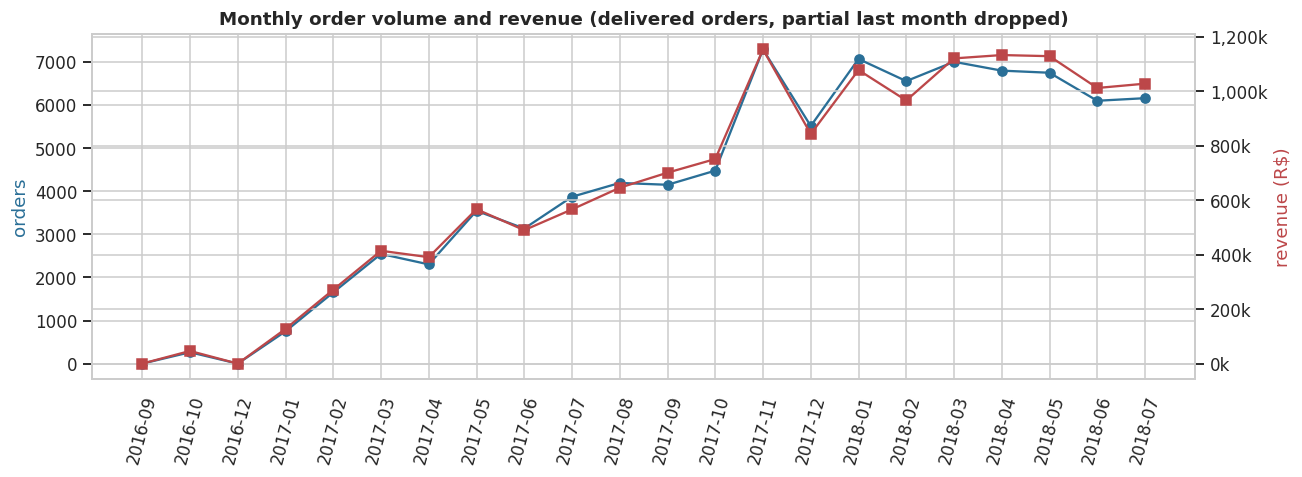

In [72]:
delivered = order[order.order_status == "delivered"].copy()
monthly = (delivered.groupby("purchase_month")
           .agg(orders=("order_id", "nunique"), revenue=("order_total", "sum")).reset_index())
# drop the partial final month for a fair trend
monthly = monthly.iloc[:-1] if len(monthly) > 2 else monthly

fig, ax1 = plt.subplots(figsize=(12, 4.5))
ax1.plot(monthly.purchase_month, monthly.orders, marker="o", color="#2A6F97", label="orders")
ax1.set_ylabel("orders", color="#2A6F97"); ax1.tick_params(axis="x", rotation=75)
ax2 = ax1.twinx()
ax2.plot(monthly.purchase_month, monthly.revenue, marker="s", color="#BC4749", label="revenue")
ax2.set_ylabel("revenue (R$)", color="#BC4749")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:,.0f}k"))
ax1.set_title("Monthly order volume and revenue (delivered orders, partial last month dropped)")
plt.tight_layout(); plt.show()

The marketplace grows steadily through 2017–2018 with a pronounced **November 2017 spike
(Black Friday)**. Any time-based model should use time-ordered splits and can benefit from a
month / holiday feature.

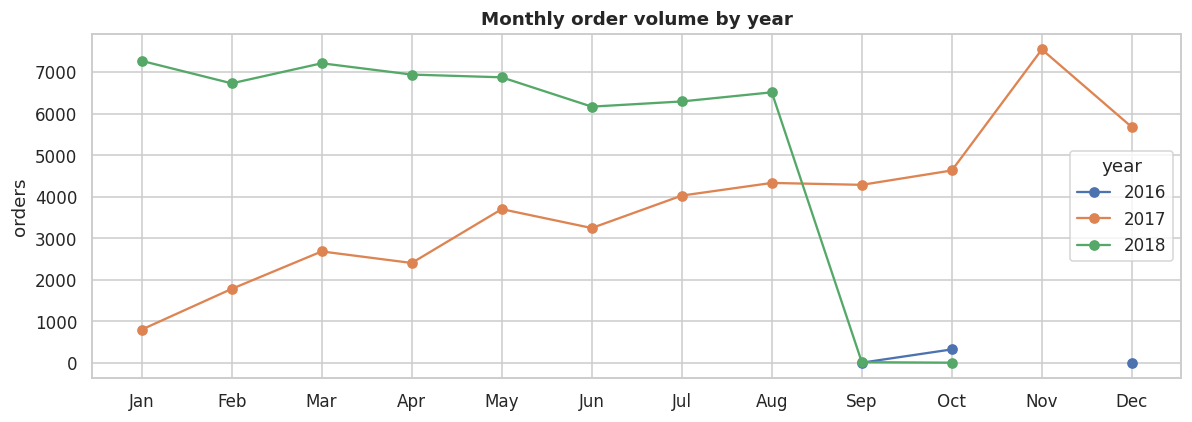

In [73]:
# Year-over-year monthly volume — makes seasonality explicit
oy = t["orders"].copy()
oy["year"] = oy.order_purchase_timestamp.dt.year
oy["mon"] = oy.order_purchase_timestamp.dt.month
piv = oy.groupby(["mon", "year"]).order_id.count().unstack("year")
fig, ax = plt.subplots(figsize=(11, 4))
for yr in piv.columns:
    ax.plot(piv.index, piv[yr], marker="o", label=str(int(yr)))
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
ax.set_ylabel("orders"); ax.set_title("Monthly order volume by year"); ax.legend(title="year")
plt.tight_layout(); plt.show()

Overlaying the years shows the platform scaling (2018 sits above 2017 for most months) and marks
the **November 2017 Black Friday** peak as a one-off rather than a recurring seasonal pattern. The
window is only ~2 years (late 2016 to Oct 2018) with a partial final month, so seasonal claims stay
cautious.

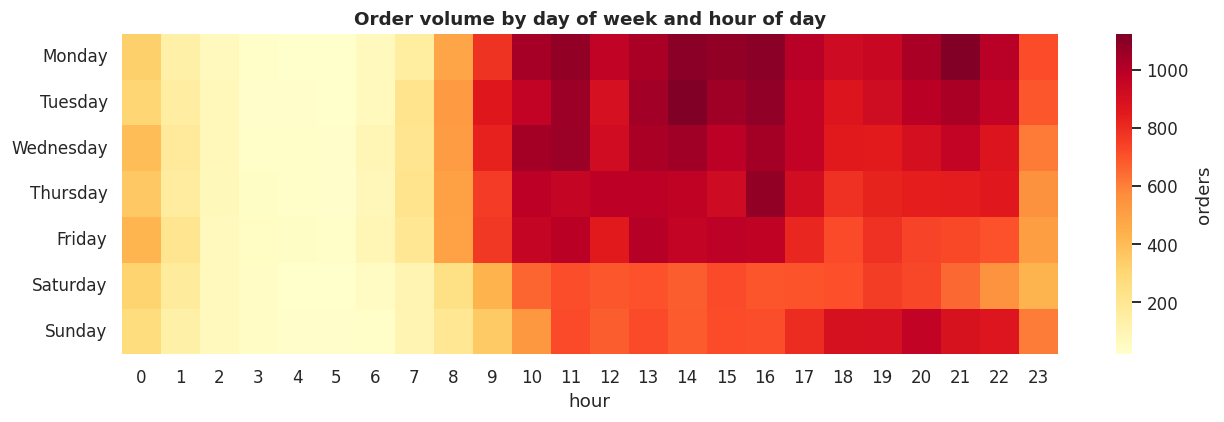

In [74]:
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
heat = (order.groupby(["purchase_dow", "purchase_hour"]).size()
        .reset_index(name="n").pivot(index="purchase_dow", columns="purchase_hour", values="n")
        .reindex(dow_order))
fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(heat, cmap="YlOrRd", ax=ax, cbar_kws={"label": "orders"})
ax.set_title("Order volume by day of week and hour of day")
ax.set_xlabel("hour"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

Buying concentrates on weekday business hours with an afternoon peak — useful for capacity planning, but (as section 5 shows) purchase timing barely moves late-delivery rate.

## 5. Delivery performance

Restricting to delivered orders, we decompose the lead time, measure lateness against Olist's own
estimate, and show the strong geographic gradient.

Delivered orders: 96,478  (97.0% of all orders)
Late vs estimate: 6.8%  |  early: 91.9%
days vs estimate — median -12 (neg = early); only 2.4% are >30d early, 0.4% >30d late (range -147 to 188)
mean    12.10
50%     10.00
max    209.00


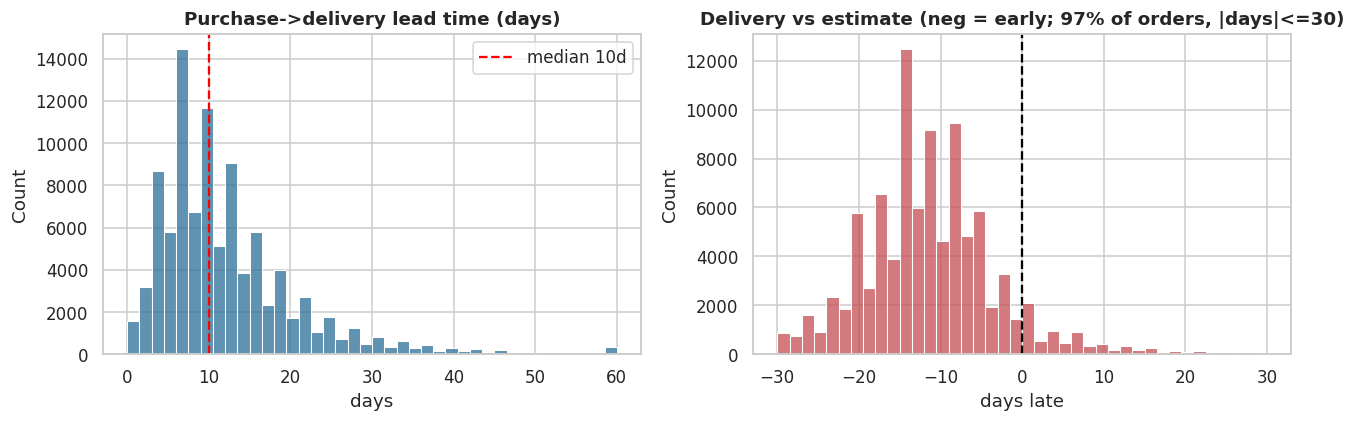

In [75]:
d = delivered.dropna(subset=["delivery_days"]).copy()
print(f"Delivered orders: {len(delivered):,}  ({len(delivered)/len(order)*100:.1f}% of all orders)")
print(f"Late vs estimate: {d.is_late.mean()*100:.1f}%  |  early: {(d.days_late<0).mean()*100:.1f}%")
print(f"days vs estimate — median {d.days_late.median():.0f} (neg = early); "
      f"only {(d.days_late<-30).mean()*100:.1f}% are >30d early, {(d.days_late>30).mean()*100:.1f}% >30d late "
      f"(range {int(d.days_late.min())} to {int(d.days_late.max())})")
print(d["delivery_days"].describe()[["mean","50%","max"]].round(1).to_string())

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(d.delivery_days.clip(0, 60), bins=40, ax=ax[0], color="#2A6F97")
ax[0].axvline(d.delivery_days.median(), color="red", ls="--",
              label=f"median {d.delivery_days.median():.0f}d"); ax[0].legend()
ax[0].set_title("Purchase->delivery lead time (days)"); ax[0].set_xlabel("days")
# Show only the +/-30d window, EXCLUDING the thin tails (not clipping them onto the edge bins,
# which would create a misleading spike). ~2-3% of orders fall outside this range.
mid = d.days_late[d.days_late.between(-30, 30)]
sns.histplot(mid, bins=40, ax=ax[1], color="#C44E52")
ax[1].axvline(0, color="black", ls="--")
ax[1].set_title("Delivery vs estimate (neg = early; %.0f%% of orders, |days|<=30)" % (len(mid)/len(d)*100))
ax[1].set_xlabel("days late")
plt.tight_layout(); plt.show()

Deliveries beat the estimate far more often than they miss it: the median order arrives **~12 days
early**, because Olist's promised dates are padded — median *estimate* ~23 days against ~10 days of
actual transit, roughly 13 days of built-in slack. Earliness clusters around 7–17 days; genuinely
extreme cases (a month or more early, out to ~150 days) are a thin ~2–3% tail. The histogram shows
only the ±30-day window and **excludes** that tail rather than clipping it onto the edge, which would
otherwise pile the whole tail into one misleadingly tall bar.

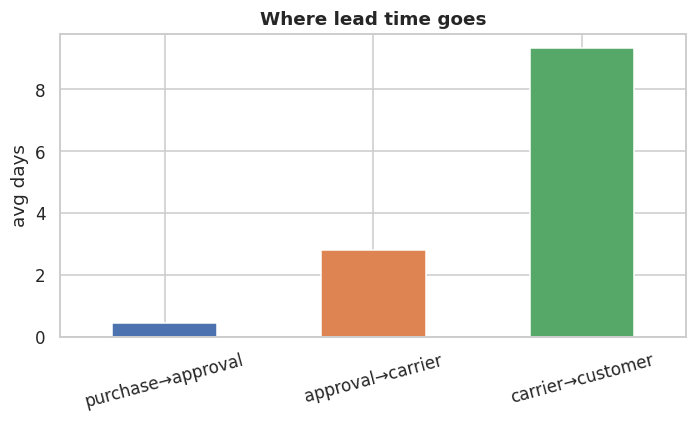

to_approval       0.43
to_carrier        2.80
carrier_to_cust   9.33


In [76]:
# lead-time decomposition into the three operational stages
dd = delivered.copy()
dd["to_approval"] = (dd.order_approved_at - dd.order_purchase_timestamp).dt.total_seconds()/86400
dd["to_carrier"] = (dd.order_delivered_carrier_date - dd.order_approved_at).dt.total_seconds()/86400
dd["carrier_to_cust"] = (dd.order_delivered_customer_date
                         - dd.order_delivered_carrier_date).dt.total_seconds()/86400
stages = dd[["to_approval","to_carrier","carrier_to_cust"]].mean()
fig, ax = plt.subplots(figsize=(6.5, 4))
stages.plot(kind="bar", ax=ax, color=["#4C72B0","#DD8452","#55A868"])
ax.set_xticklabels(["purchase→approval","approval→carrier","carrier→customer"], rotation=15)
ax.set_ylabel("avg days"); ax.set_title("Where lead time goes")
plt.tight_layout(); plt.show()
print(stages.round(2).to_string())

Most of the wait is the **carrier→customer leg** (~9 days), not seller handling — the delay is logistics, not approval.

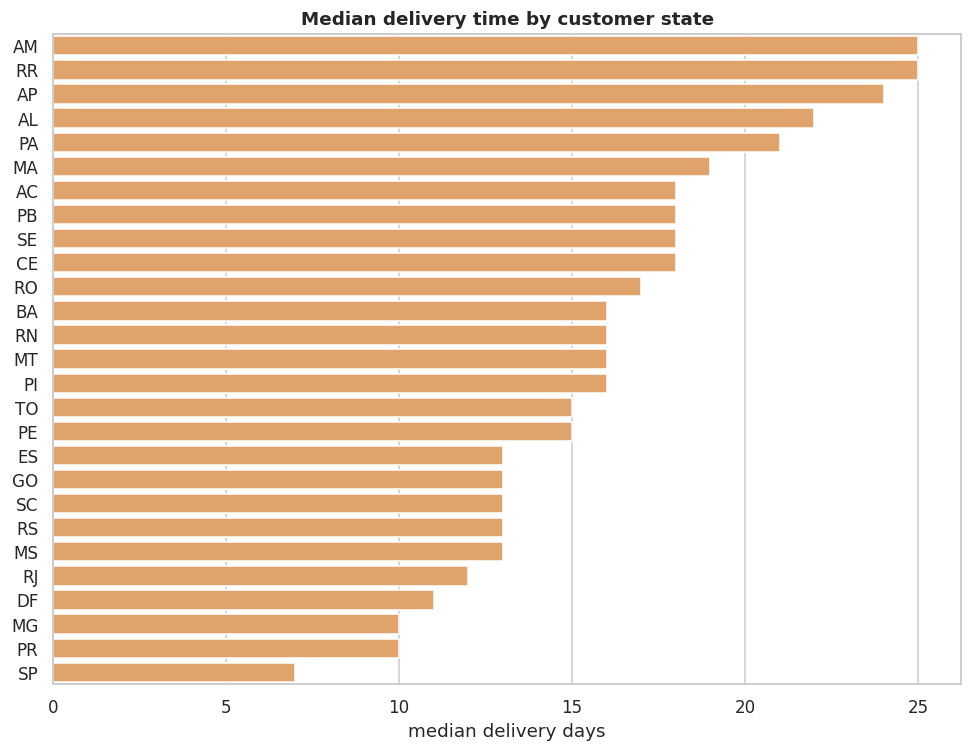

Fastest/slowest states:
customer_state
AM   25.00
RR   25.00
AP   24.00
customer_state
MG   10.00
PR   10.00
SP    7.00


In [77]:
state = (d.groupby("customer_state")
         .agg(orders=("order_id","count"), median_days=("delivery_days","median"),
              late_rate=("is_late","mean")).sort_values("median_days", ascending=False))
state["late_rate"] = (state.late_rate*100).round(1)
fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(x=state.median_days, y=state.index, ax=ax, color="#F4A259")
ax.set_xlabel("median delivery days"); ax.set_ylabel("")
ax.set_title("Median delivery time by customer state")
plt.tight_layout(); plt.show()
print("Fastest/slowest states:")
print(state.median_days.head(3).to_string()); print(state.median_days.tail(3).to_string())

A strong geographic gradient: São Paulo (where most sellers sit) gets orders in ~8 days with <6% late; remote northern states (e.g. RR, AP, AM) wait 2–3× as long. Distance is the dominant driver of both delivery time and freight (§7).

## 6. Customer, seller and product distributions

All three actor tables are highly skewed — a small share of customers, sellers and categories
account for most of the activity.

Distinct customers: 96,096 | repeat (>1 order): 3.12%
Sellers: 3,095 | top 543 sellers (18%) make 80% of item revenue
Sellers are geographically concentrated — top states: SP 60%, PR 11%, MG 8%


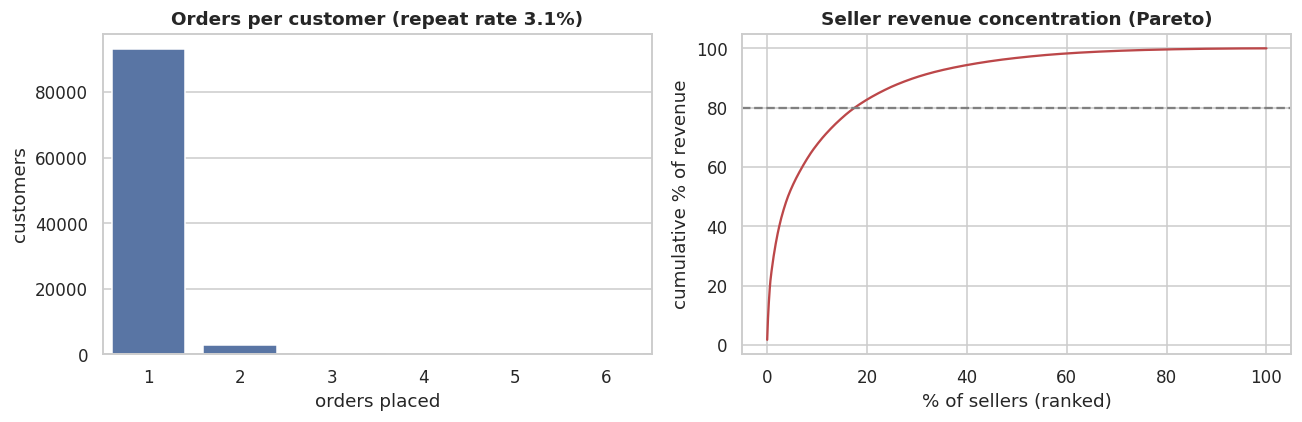

In [78]:
# ---- Customers: repeat behaviour ----
orders_per_cust = t["customers"].groupby("customer_unique_id")["customer_id"].nunique()
repeat_rate = (orders_per_cust > 1).mean()*100
print(f"Distinct customers: {orders_per_cust.size:,} | repeat (>1 order): {repeat_rate:.2f}%")

# ---- Sellers: Pareto ----
seller_rev = item.groupby("seller_id")["price"].sum().sort_values(ascending=False)
cum = seller_rev.cumsum() / seller_rev.sum()
top_share = (cum <= 0.8).sum()
print(f"Sellers: {seller_rev.size:,} | top {top_share:,} sellers "
      f"({top_share/seller_rev.size*100:.0f}%) make 80% of item revenue")
ss = t["sellers"].seller_state.value_counts(normalize=True).mul(100).round(1)
print("Sellers are geographically concentrated — top states: " +
      ", ".join(f"{s} {p:.0f}%" for s, p in ss.head(3).items()))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
od = orders_per_cust.value_counts().sort_index().head(6)
sns.barplot(x=od.index.astype(str), y=od.values, ax=ax[0], color="#4C72B0")
ax[0].set_title(f"Orders per customer (repeat rate {repeat_rate:.1f}%)")
ax[0].set_xlabel("orders placed"); ax[0].set_ylabel("customers")
ax[1].plot(np.arange(1, len(cum)+1)/len(cum)*100, cum.values*100, color="#BC4749")
ax[1].axhline(80, color="grey", ls="--"); ax[1].set_xlabel("% of sellers (ranked)")
ax[1].set_ylabel("cumulative % of revenue"); ax[1].set_title("Seller revenue concentration (Pareto)")
plt.tight_layout(); plt.show()

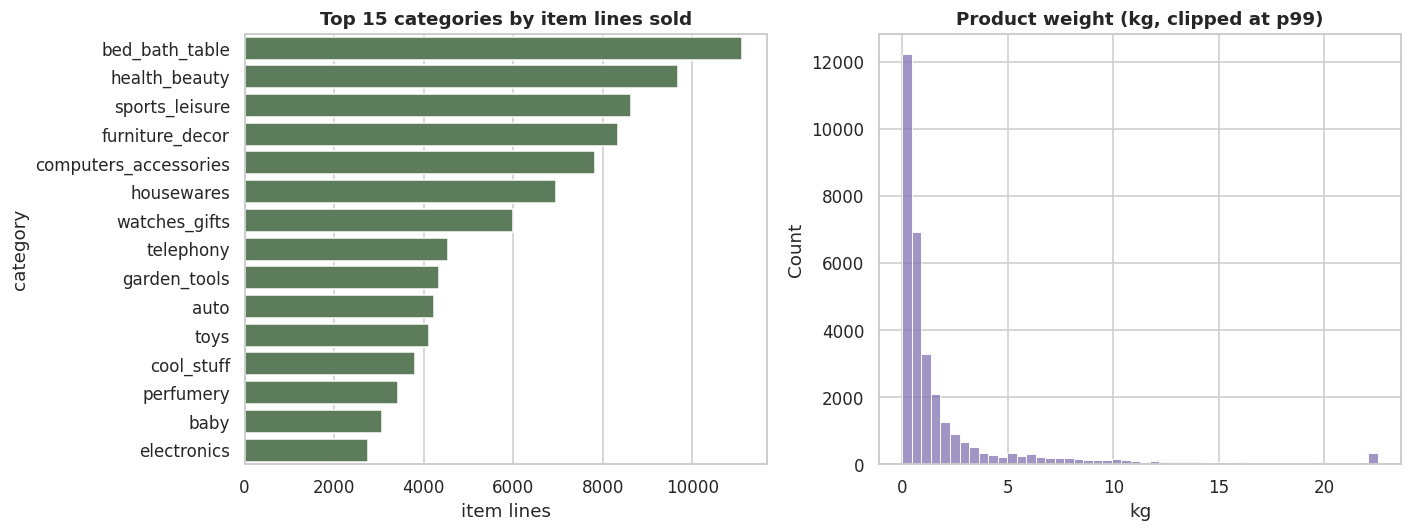

Distinct categories: 74


In [79]:
# ---- Products: category counts and physical size ----
cat_counts = item["category"].value_counts().head(15)
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(x=cat_counts.values, y=cat_counts.index, ax=ax[0], color="#588157")
ax[0].set_title("Top 15 categories by item lines sold"); ax[0].set_xlabel("item lines")
sns.histplot(prod["weight_kg"].clip(upper=prod["weight_kg"].quantile(0.99)),
             bins=50, ax=ax[1], color="#8172B2")
ax[1].set_title("Product weight (kg, clipped at p99)"); ax[1].set_xlabel("kg")
plt.tight_layout(); plt.show()
print("Distinct categories:", item["category"].nunique())

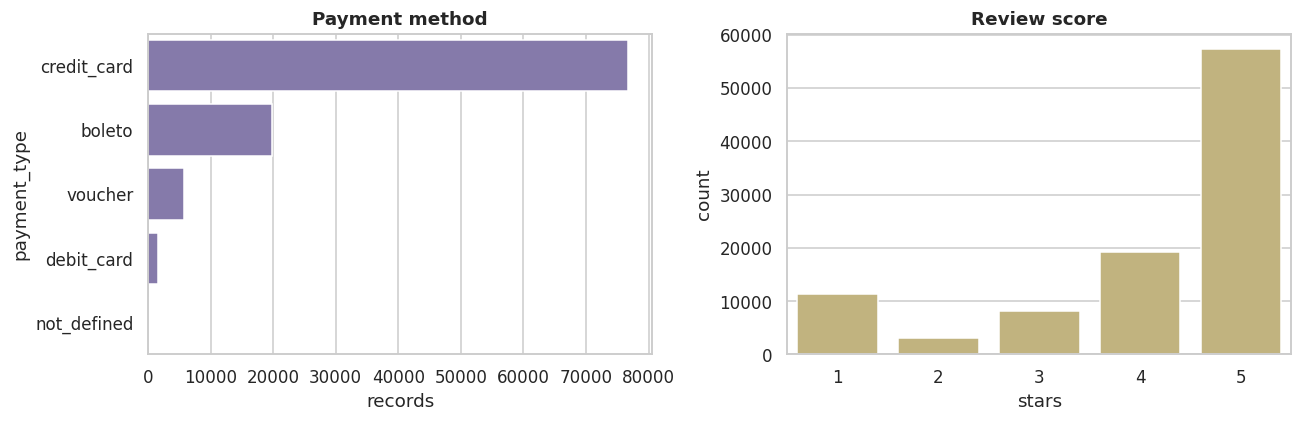

5-star: 57.8% | 1-star: 11.5%


In [80]:
# ---- Payments ----
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
pv = t["payments"]["payment_type"].value_counts()
sns.barplot(x=pv.values, y=pv.index, ax=ax[0], color="#8172B2")
ax[0].set_title("Payment method"); ax[0].set_xlabel("records")
rv = t["reviews"]["review_score"].value_counts().sort_index()
sns.barplot(x=rv.index, y=rv.values, ax=ax[1], color="#CCB974")
ax[1].set_title("Review score"); ax[1].set_xlabel("stars"); ax[1].set_ylabel("count")
plt.tight_layout(); plt.show()
print(f"5-star: {(t['reviews'].review_score==5).mean()*100:.1f}% | "
      f"1-star: {(t['reviews'].review_score==1).mean()*100:.1f}%")

**What this means for problem choice.** All three actor tables are heavily skewed, and that rules
some targets in and others out. The **~3% repeat rate** makes any repeat-purchase / customer-lifetime-
value target a rare-event problem on a thin signal — so we do *not* pursue it. Seller revenue is
Pareto-concentrated, which keeps the door open for a seller-level target (Candidate C) but warns that
most sellers are too small to model individually. Reviews are bimodal and, as flagged in §2, their
**text is majority-empty — usable only as a 1–5 score, not for text mining.** None of these points to a
customer- or review-centred problem; the strongest, densest signal remains **freight and delivery**,
which we pursue in §7–§9.

## 7. Freight economics — the central theme

Three independent analyses converged here, so this is the spine of the project. Freight is a large,
systematic cost, and it is driven by the **physical shipment (weight, volume, distance)** far more
than by the item's price.

Freight as % of item price  — median 23.1%, mean 32.1%
Share of items with freight > 25% of price: 46.0%
Freight as % of total GMV   — 14.2%


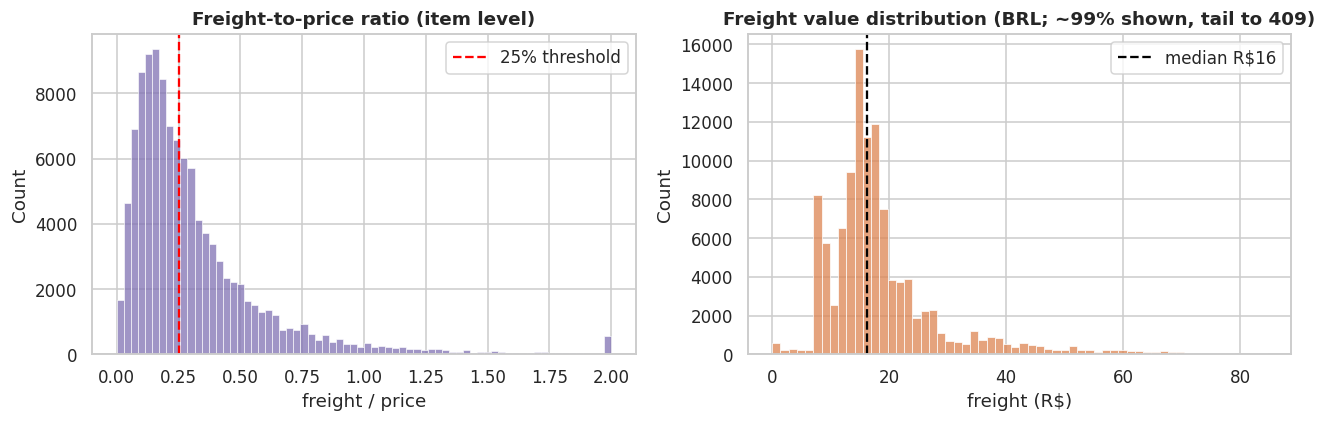

In [81]:
f = item.dropna(subset=["freight_ratio"]).copy()
f = f[(f.price > 0) & (f.freight_value >= 0)]
print("Freight as %% of item price  — median %.1f%%, mean %.1f%%"
      % (f.freight_ratio.median()*100, f.freight_ratio.mean()*100))
print("Share of items with freight > 25%% of price: %.1f%%" % ((f.freight_ratio > 0.25).mean()*100))
FREIGHT_GMV = item.freight_value.sum()/(item.freight_value.sum()+item.price.sum())*100
print("Freight as %% of total GMV   — %.1f%%" % FREIGHT_GMV)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(f.freight_ratio.clip(upper=2), bins=70, ax=ax[0], color="#8172B3")
ax[0].axvline(0.25, color="red", ls="--", label="25% threshold"); ax[0].legend()
ax[0].set_title("Freight-to-price ratio (item level)"); ax[0].set_xlabel("freight / price")
cap = f.freight_value.quantile(0.99)
sns.histplot(f.freight_value[f.freight_value <= cap], bins=60, ax=ax[1], color="#DD8452")
ax[1].axvline(f.freight_value.median(), color="black", ls="--",
              label="median R$%.0f" % f.freight_value.median()); ax[1].legend()
ax[1].set_title("Freight value distribution (BRL; ~99%% shown, tail to %d)" % f.freight_value.max())
ax[1].set_xlabel("freight (R$)")
plt.tight_layout(); plt.show()

The raw distribution shows freight clustering tightly around **15–20 reais** (median R$16),
tapering through the 30–60 range, with a thin right tail of heavy or long-haul shipments running out
to about 410 reais (roughly 1% of items sit above the ~80 view shown here). The shape is
right-skewed — which is why the *modelling* step in §9 log-transforms freight and its drivers, even
though the distribution itself is shown here in Reais.

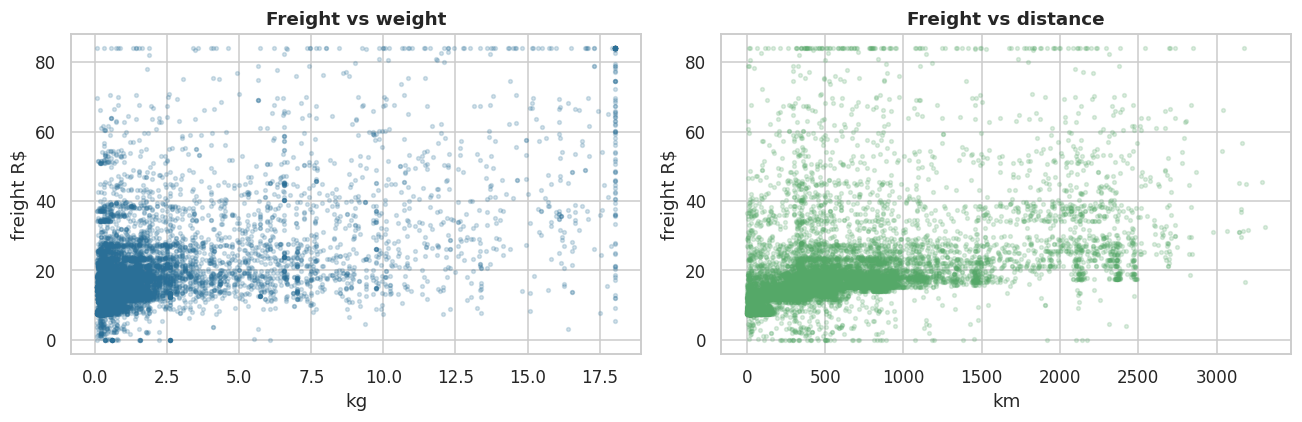

Pearson freight vs weight  : 0.612
Pearson freight vs volume  : 0.587
Pearson freight vs distance: 0.390
Pearson freight vs price   : 0.415


In [82]:
# freight vs the physical drivers
core = f.dropna(subset=["distance_km", "weight_kg", "volumetric_weight_kg"])
core = core[(core.weight_kg > 0)]
samp = core.sample(min(12000, len(core)), random_state=RANDOM_STATE)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(samp.weight_kg.clip(upper=samp.weight_kg.quantile(.99)),
              samp.freight_value.clip(upper=samp.freight_value.quantile(.99)),
              s=6, alpha=0.2, color="#2A6F97")
ax[0].set_title("Freight vs weight"); ax[0].set_xlabel("kg"); ax[0].set_ylabel("freight R$")
ax[1].scatter(samp.distance_km, samp.freight_value.clip(upper=samp.freight_value.quantile(.99)),
              s=6, alpha=0.2, color="#55A868")
ax[1].set_title("Freight vs distance"); ax[1].set_xlabel("km"); ax[1].set_ylabel("freight R$")
plt.tight_layout(); plt.show()
print("Pearson freight vs weight  : %.3f" % core[["weight_kg","freight_value"]].corr().iloc[0,1])
print("Pearson freight vs volume  : %.3f" % core[["volumetric_weight_kg","freight_value"]].corr().iloc[0,1])
print("Pearson freight vs distance: %.3f" % core[["distance_km","freight_value"]].corr().iloc[0,1])
print("Pearson freight vs price   : %.3f" % core[["price","freight_value"]].corr().iloc[0,1])

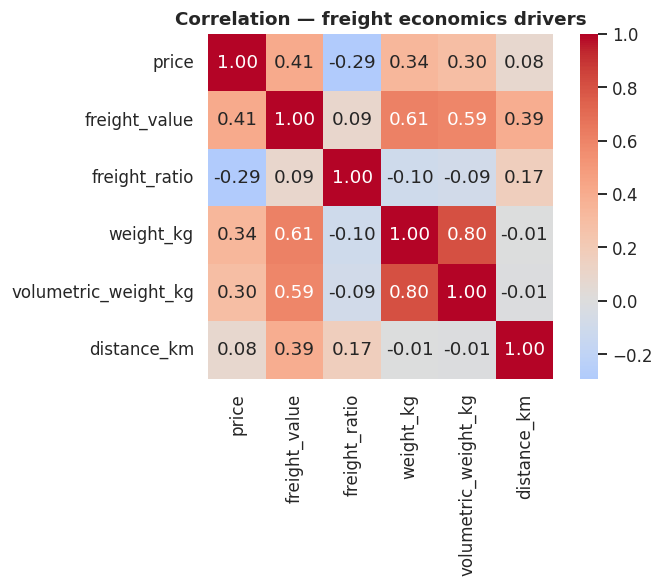

In [83]:
# correlation heatmap of the freight drivers
cols = ["price","freight_value","freight_ratio","weight_kg","volumetric_weight_kg","distance_km"]
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(core[cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, ax=ax)
ax.set_title("Correlation — freight economics drivers")
plt.tight_layout(); plt.show()

Freight correlates ~0.6 with weight and volume and ~0.4 with distance, but only ~0.4 with price —
confirming freight is priced off the parcel. **Weight and volumetric weight are themselves ~0.8
correlated**, so a model should not use both raw (combine them or use a tree model).

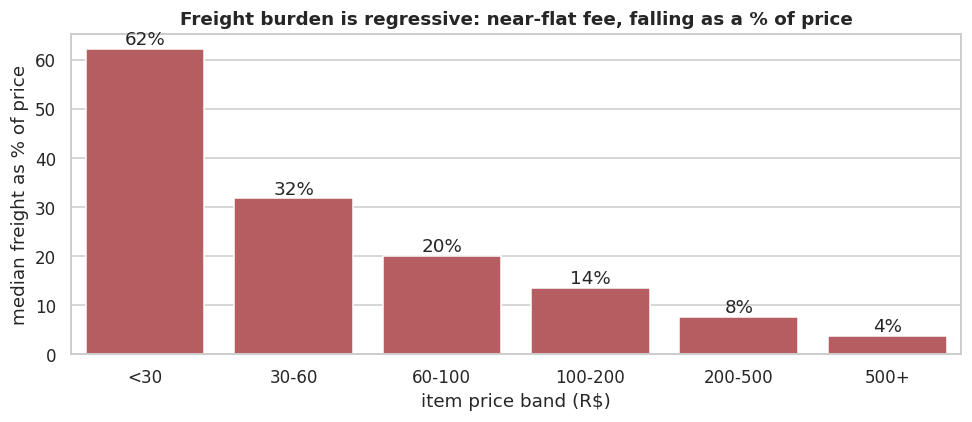

         median_freight  median_burden
price                                 
<30               14.10          62.20
30-60             15.10          31.80
60-100            16.35          20.10
100-200           18.54          13.50
200-500           21.00           7.70
500+              31.28           3.80


In [84]:
# Regressive freight: a near-flat fee is a big % of cheap items
band = pd.cut(f.price, [0,30,60,100,200,500,np.inf],
              labels=["<30","30-60","60-100","100-200","200-500","500+"])
bstats = f.groupby(band, observed=True).agg(median_freight=("freight_value","median"),
                                            median_burden=("freight_ratio","median"))
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(x=bstats.index.astype(str), y=(bstats.median_burden*100).values, ax=ax, color="#C44E52")
for i, v in enumerate(bstats.median_burden*100):
    ax.text(i, v, f"{v:.0f}%", ha="center", va="bottom")
ax.set_title("Freight burden is regressive: near-flat fee, falling as a % of price")
ax.set_xlabel("item price band (R$)"); ax.set_ylabel("median freight as % of price")
plt.tight_layout(); plt.show()
print(bstats.assign(median_burden=lambda d:(d.median_burden*100).round(1)).to_string())

Median freight is roughly flat across price bands (~R$14–31), so as a **share of price** it falls
from ~60% on the cheapest items to ~4% on the dearest. Cheap-but-bulky categories (electronics,
telephony) are structurally penalised — the commercial hook behind the modelling problem.

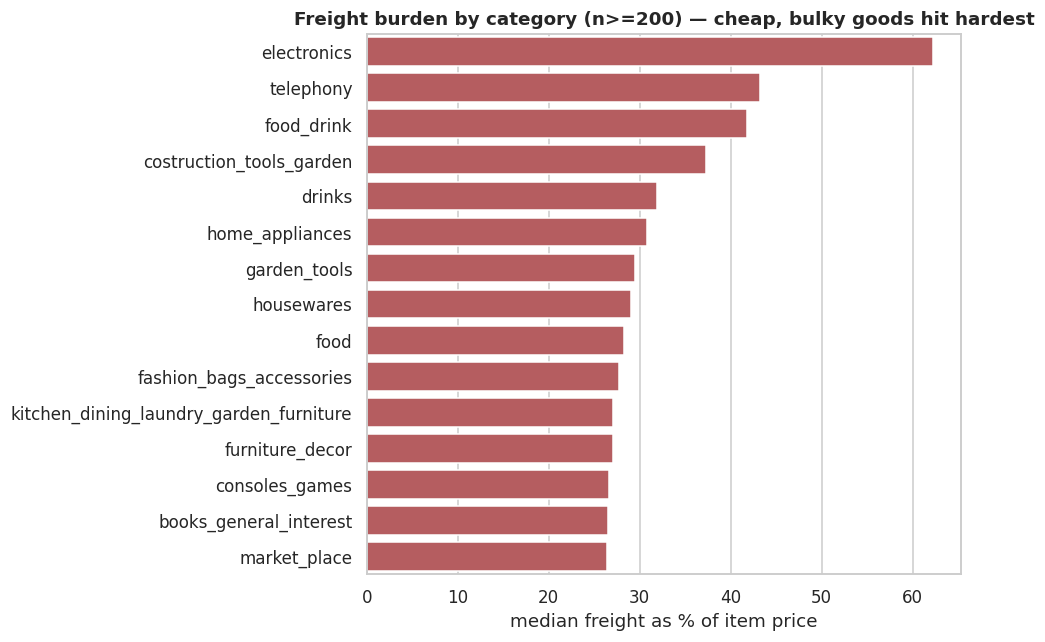

Near-identical freight, opposite burden:
               median_price  median_freight  median_burden
category                                                  
electronics           21.90           15.10          62.00
watches_gifts        129.00           15.82          12.00


In [85]:
# Freight burden by product category
catburden = (f.groupby("category")
             .agg(median_burden=("freight_ratio", "median"),
                  median_freight=("freight_value", "median"),
                  median_price=("price", "median"),
                  n=("freight_ratio", "size"))
             .query("n >= 200").sort_values("median_burden", ascending=False))
top = catburden.head(15)
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=(top.median_burden*100).values, y=top.index, ax=ax, color="#C44E52")
ax.set_xlabel("median freight as % of item price"); ax.set_ylabel("")
ax.set_title("Freight burden by category (n>=200) — cheap, bulky goods hit hardest")
plt.tight_layout(); plt.show()

comp = catburden.loc[catburden.index.intersection(["electronics", "watches_gifts"])]
print("Near-identical freight, opposite burden:")
print(comp[["median_price", "median_freight", "median_burden"]]
      .assign(median_burden=lambda d: (d.median_burden*100).round(0)).to_string())

Electronics and watches_gifts pay almost the **same absolute freight** (~R$15), yet electronics
carries ~60% burden against ~12% for watches — purely because electronics items are cheap and watches
are dear. Category is therefore a strong signal for the freight model and pinpoints who a fairer
freight policy would help most.

## 8. Customer Reviews - what drives satisfication

In this section, we investigate the distribution of customer satisfaction levels and the key influencing factors.

### 8.1 Distribution of Reviews

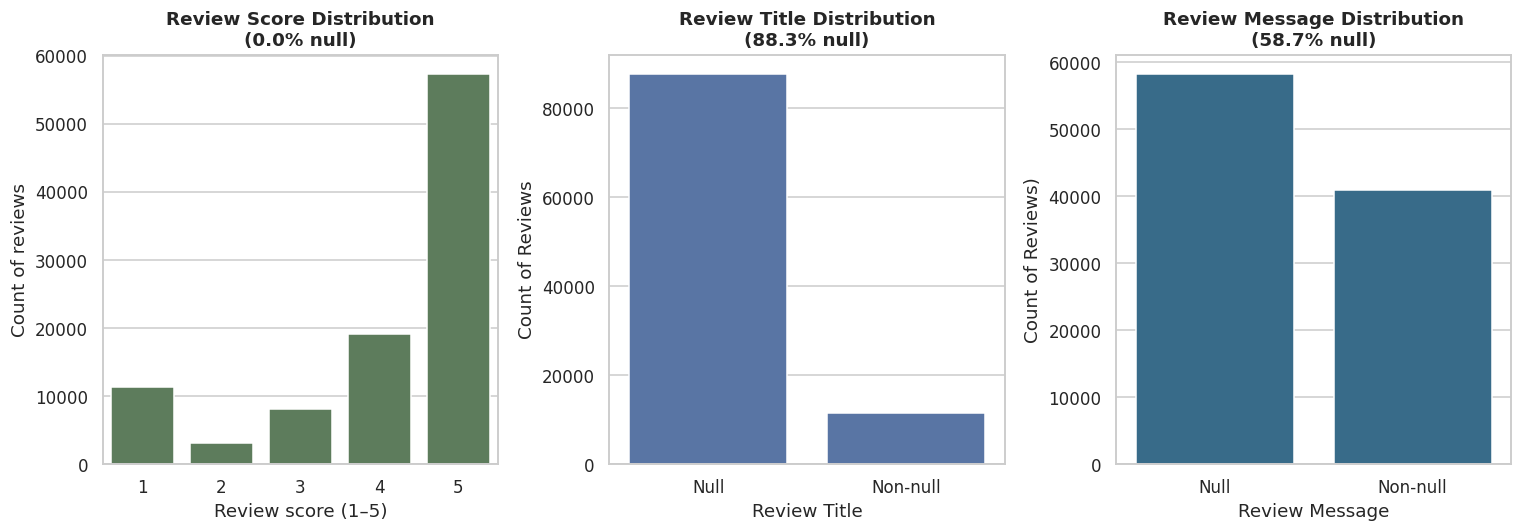

In [86]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

review_counts = t['reviews']["review_score"].value_counts().sort_index()
sns.barplot(x=review_counts.index, y=review_counts.values, ax=axes[0], color="#588157")
axes[0].set_xlabel("Review score (1–5)")
axes[0].set_ylabel("Count of reviews")
axes[0].set_title(f"Review Score Distribution\n({100-len(t['reviews']['review_score'].isna()) / len(t['reviews']['review_score'])*100}% null)")

# Plot for review_comment_title
review_title_sparsity = t['reviews']["review_comment_title"].isna().value_counts().rename({False: 'Non-null', True: 'Null'})
sns.barplot(x=review_title_sparsity.index, y=review_title_sparsity.values, ax=axes[1])
axes[1].set_xlabel("Review Title")
axes[1].set_title(f"Review Title Distribution\n({round(100-review_title_sparsity['Non-null']/(review_title_sparsity['Non-null']+review_title_sparsity['Null']) * 100, 1)}% null)")
axes[1].set_ylabel('Count of Reviews')

# Plot for review_comment_message
review_message_sparsity = t['reviews']["review_comment_message"].isna().value_counts().rename({False: 'Non-null', True: 'Null'})
sns.barplot(x=review_message_sparsity.index, y=review_message_sparsity.values, ax=axes[2], color="#2A6F97")
axes[2].set_xlabel("Review Message")
axes[2].set_title(f"Review Message Distribution\n({round(100-review_message_sparsity['Non-null']/(review_message_sparsity['Non-null']+review_message_sparsity['Null']) * 100, 1)}% null)")
axes[2].set_ylabel('Count of Reviews)')

plt.tight_layout()
plt.show()

There are three columns indicating customers' satisfaction in the reviews dataset.
* Review Score:
    * Numerical column ranging from 1-5 with no null values, making it a useful feature to directly measure satisfation
    * Satisfaction levels are more prominent on the extremes, with significantly more 5-star than 1-star reviews (~5 times more)
* Review Title and Message:
    * Large proportion of null values, hence might not be suitable for direct analysis without extensive imputation or feature engineering

### 8.2 Review Distribution over Time

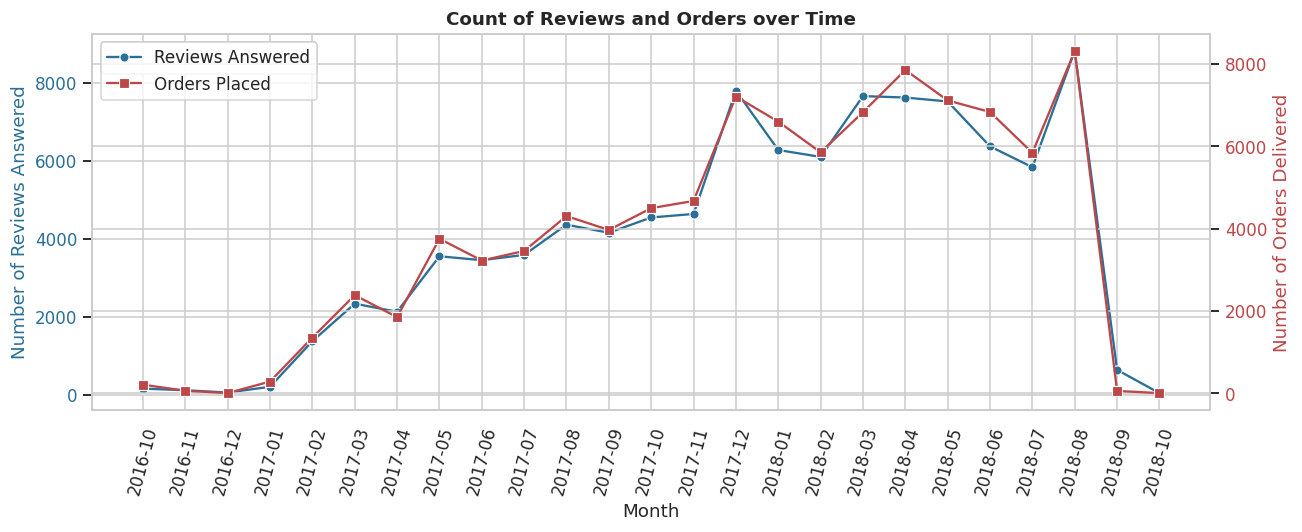

In [87]:
reviews_monthly = (t['reviews'].dropna(subset=['review_answer_timestamp'])
                     .assign(review_month=lambda x: x['review_answer_timestamp'].dt.to_period('M').astype(str))
                     .groupby('review_month')['review_id'].count()
                     .reset_index(name='num_reviews'))

orders_monthly = (t['orders']
                     .assign(delivered_month=lambda x: x['order_delivered_customer_date'].dt.to_period('M').astype(str))
                     .groupby('delivered_month')['order_id'].nunique()
                    .reset_index(name='num_orders'))

merged_data = pd.merge(reviews_monthly, orders_monthly, left_on='review_month', right_on='delivered_month', how='outer')
merged_data = merged_data.sort_values('review_month')

fig, ax1 = plt.subplots(figsize=(12, 5))

sns.lineplot(x='review_month', y='num_reviews', data=merged_data, marker='o', color='#2A6F97', ax=ax1, label='Reviews Answered')
ax1.set_xlabel('Month')
ax1.set_ylabel('Number of Reviews Answered', color='#2A6F97')
ax1.tick_params(axis='x', rotation=75)
ax1.tick_params(axis='y', labelcolor='#2A6F97')

ax2 = ax1.twinx()  # Create a twin y-axis
sns.lineplot(x='review_month', y='num_orders', data=merged_data, marker='s', color='#BC4749', ax=ax2, label='Orders Placed')
ax2.set_ylabel('Number of Orders Delivered', color='#BC4749')
ax2.tick_params(axis='y', labelcolor='#BC4749')

ax1.set_title('Count of Reviews and Orders over Time')

# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.tight_layout()
plt.show()


* Review and Order volume show similar trends over time. This suggests that most customers review their products within the same month of receiving them.
* One possible reason is that the platform requires reviews to be made within one month of receiving the product.
* We also observe that review volume is high relative to order volume, i.e. review completion rate is high.
* Given the short turnaround time between receiving the product and writing the review, we can infer that reviews are more focused on delivery performance and product appearance, rather than product quality or longer term usability.

### 8.3 Correlation Analysis

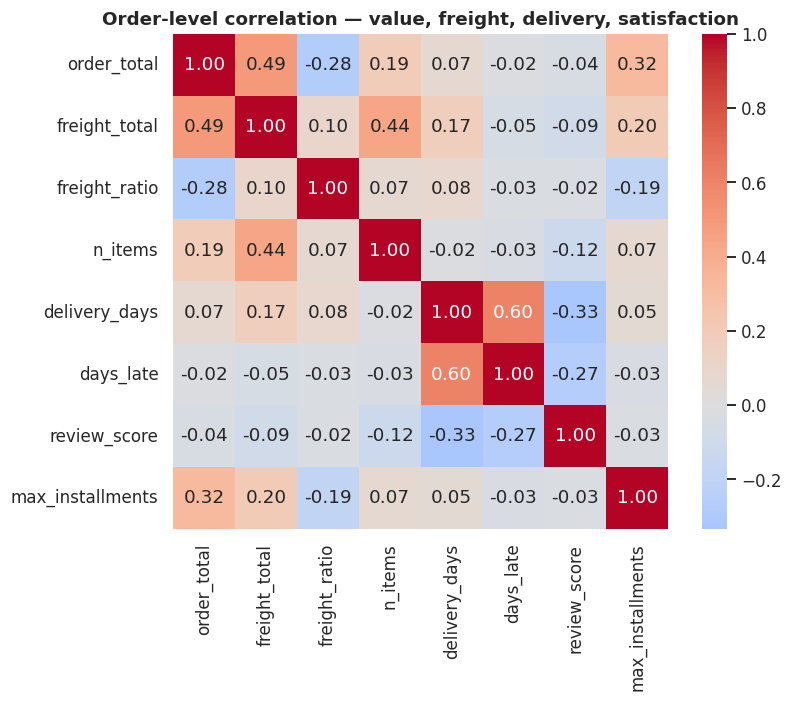

In [88]:
# Order-level relationships, on delivered orders that carry a review
rel = order[(order.order_status == "delivered") & order.review_score.notna()].copy()
num = ["order_total", "freight_total", "freight_ratio", "n_items",
       "delivery_days", "days_late", "review_score", "max_installments"]
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(rel[num].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, ax=ax)
ax.set_title("Order-level correlation — value, freight, delivery, satisfaction")
plt.tight_layout(); plt.show()

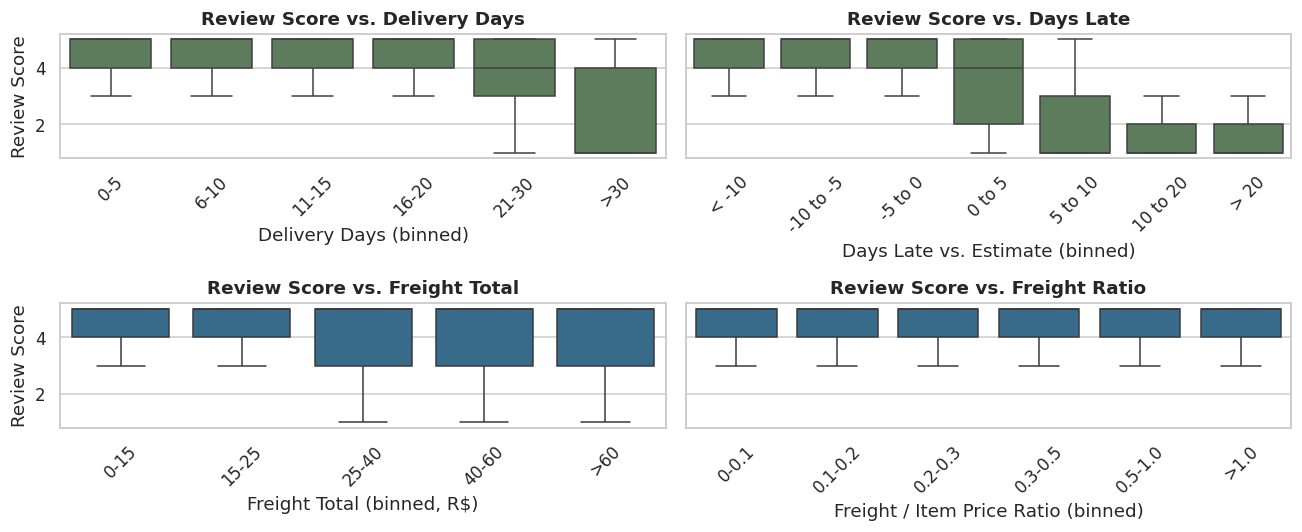

In [89]:
# Binning delivery days
delivery_bins = [0, 5, 10, 15, 20, 30, rel['delivery_days'].max() + 1]
delivery_labels = ['0-5', '6-10', '11-15', '16-20', '21-30', '>30']
rel['delivery_days_binned'] = pd.cut(rel['delivery_days'], bins=delivery_bins, labels=delivery_labels, right=False)

# Binning days late (days_late)
days_late_bins = [rel['days_late'].min() - 1, -10, -5, 0, 5, 10, 20, rel['days_late'].max() + 1]
days_late_labels = ['< -10', '-10 to -5', '-5 to 0', '0 to 5', '5 to 10', '10 to 20', '> 20']
rel['days_late_binned'] = pd.cut(rel['days_late'], bins=days_late_bins, labels=days_late_labels, right=False)

# Binning freight total
freight_bins = [0, 15, 25, 40, 60, rel['freight_total'].max() + 1]
freight_labels = ['0-15', '15-25', '25-40', '40-60', '>60']
rel['freight_total_binned'] = pd.cut(rel['freight_total'], bins=freight_bins, labels=freight_labels, right=False)

# Binning freight ratio
freight_ratio_bins = [0, 0.1, 0.2, 0.3, 0.5, 1.0, rel['freight_ratio'].max() + 0.1]
freight_ratio_labels = ['0-0.1', '0.1-0.2', '0.2-0.3', '0.3-0.5', '0.5-1.0', '>1.0']
rel['freight_ratio_binned'] = pd.cut(rel['freight_ratio'], bins=freight_ratio_bins, labels=freight_ratio_labels, right=False)

fig, axes = plt.subplots(2, 2, figsize=(12, 5), sharey=True)

# Plot 1: Review Score vs. Delivery Days
sns.boxplot(x='delivery_days_binned', y='review_score', data=rel, ax=axes[0, 0], color="#588157", showfliers=False)
axes[0, 0].set_title('Review Score vs. Delivery Days')
axes[0, 0].set_xlabel('Delivery Days (binned)')
axes[0, 0].set_ylabel('Review Score')
axes[0, 0].tick_params(axis='x', rotation=45)

# Plot 2: Review Score vs. Days Late
sns.boxplot(x='days_late_binned', y='review_score', data=rel, ax=axes[0, 1], color="#588157", showfliers=False)
axes[0, 1].set_title('Review Score vs. Days Late')
axes[0, 1].set_xlabel('Days Late vs. Estimate (binned)')
axes[0, 1].set_ylabel('Review Score')
axes[0, 1].tick_params(axis='x', rotation=45)

# Plot 3: Review Score vs. Freight Total
sns.boxplot(x='freight_total_binned', y='review_score', data=rel, ax=axes[1, 0], color="#2A6F97", showfliers=False)
axes[1, 0].set_title('Review Score vs. Freight Total')
axes[1, 0].set_xlabel('Freight Total (binned, R$)')
axes[1, 0].set_ylabel('Review Score')
axes[1, 0].tick_params(axis='x', rotation=45)

# Plot 4: Review Score vs. Freight Ratio
sns.boxplot(x='freight_ratio_binned', y='review_score', data=rel, ax=axes[1, 1], color="#2A6F97", showfliers=False)
axes[1, 1].set_title('Review Score vs. Freight Ratio')
axes[1, 1].set_xlabel('Freight / Item Price Ratio (binned)')
axes[1, 1].set_ylabel('Review Score')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


Correlation analysis shows that review score is more highly correlated with delivery performance (delivery_days, days_late) than pricing (order_total, freight_total, freight_ratio).

As delivery days and days late increases, the median review score decreases due to a growing accumulation of low ratings (1-2).

However, median review scores do not change as freight total or freight ratio increases. While low ratings start to appear with higher freight total, it does not seem affected by freight ratio.

## 9. Candidate problem exploration

### 9.1 Candidate A: Fair-freight pricing and overcharge detection

**Regression:** predict `freight_value` per item from distance, weight, volume and category.

**Classification:** flag items whose actual freight deviates abnormally from the predicted fair
value (a residual-based overcharge/undercharge flag built on top of the regression).

**Scoping checklist — Candidate A**

| Check | Verdict |
|---|---|
| Derivable target | `freight_value` is in order_items dataset; Anomaly label is derived from model residual |
| Realistic features | distance, weight, size, volume, category are all known at checkout - no data leakage |
| Sufficient signal | [TO ADD ON BASED ON ANALYSIS ABOVE - E.G. IS THERE STRONG CORRELATION BETWEEN FREIGHT VALUE AND DISTANCE/WEIGHT/VOLUME/CATEGORY] |
| Manageable imbalance | the anomaly flag is defined by a chosen residual percentile, so its rate is controllable.  |
| Clear stakeholder | Finance/Logistics Cost Analyst. Used to audit which sellers, routes, or product types are systematically over- or under-charging freight relative to distance and weight, informing carrier renegotiation or seller freight-policy caps. |

### 9.2 Candidate B: Delivery-time / late-delivery prediction

**Regression:** predict `delivery_days`.

**Classification:** predict `is_late` (vs Olist's estimate).

In [90]:
d.is_late.value_counts(normalize=True)

,proportion
is_late,
False,0.93
True,0.07


**Scoping checklist — Candidate B**

| Check | Verdict |
|---|---|
| Derivable target | `delivery_days` and `is_late` come from the orders dataset. |
| Realistic features | must use only pre-dispatch info (distance, product, seller, category, etc) |
| Sufficient signal | [TO ADD ON BASED ON ANALYSIS ABOVE - E.G. IS THERE STRONG CORRELATION BETWEEN DELIVERY DAYS / IS LATE AND OTHER FEATURES?] |
| Manageable imbalance | ~7% late — use precision/recall/F1 and stratified splits, not accuracy. |
| Clear stakeholder | Operations / customer-experience team setting delivery promises and flagging at-risk orders. |

## 10. Key insights and recommended direction (TO DO AFTER EVERYONE'S PARTS)

**What the data shows**
1. **Freight is a large, systematic cost** — ~14% of GMV, a median 23% of item price, and >25% of
   price on ~46% of items.
2. **Freight is priced off the parcel, not the price** — correlations ~0.6 (weight, volume) and ~0.4
   (distance) vs ~0.4 (price); weight and volume are ~0.8 collinear.
3. **Freight is regressive** — a near-flat fee is 60%+ of cheap items and <4% of expensive ones,
   structurally penalising cheap-but-bulky categories.
4. **Distance drives both freight and delivery time**, and there is a strong SP-vs-remote gradient.
5. **Satisfaction is driven by delivery time, not freight** — review score correlates −0.33 with
   delivery time (on-time 4.3★ vs late 2.3★) but is essentially flat across freight burden. This
   keeps the project honest about what freight does and does not explain.

**Recommended Phase 2 direction.** Take **Candidate A — fair-freight pricing + overcharge
detection** as the primary problem (one regression + one derived classification, satisfying the
dual-framing requirement), with **Candidate B (delivery/lateness)** as the companion logistics
problem if a second is pursued. Candidate C is held as an alternative.

**Limitations (apply to all).** `freight_value` is revenue, not carrier cost, so no true margin
claims; distances are great-circle, not road; everything conditions on completed orders (pre-
checkout demand loss is unobservable); the window is ~2 years ending Oct 2018 with a partial final
month.

---
*Reproducibility: `RANDOM_STATE = 42` throughout; analytical tables built once in §3; delivery
analysis restricted to delivered orders; log transforms used for skewed monetary variables.*